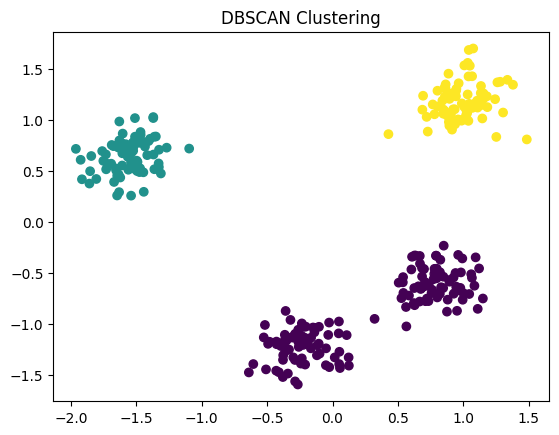

DBSCAN Silhouette Score: 0.743594601645247


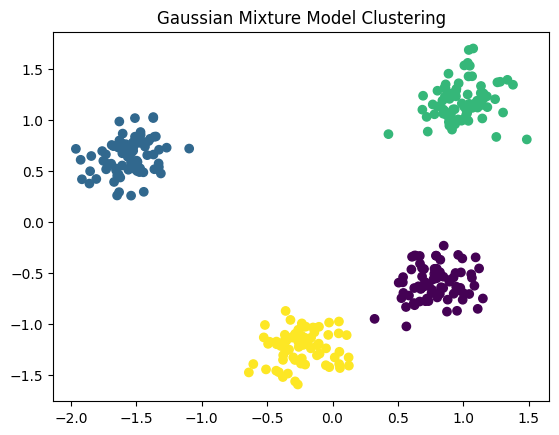

GMM Silhouette Score: 0.7974739889632732
Davies Bouldin Score: 0.2811066469065262
Calinski Harabasz Score: 3290.737330989358


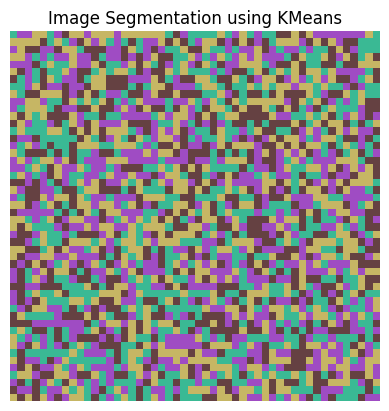

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# --------------------------------
# Generate Dataset
# --------------------------------
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# --------------------------------
# DBSCAN CLUSTERING
# --------------------------------

db = DBSCAN(eps=0.5, min_samples=5)

labels_db = db.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN Clustering")
plt.show()

print("DBSCAN Silhouette Score:", silhouette_score(X_scaled, labels_db))


# --------------------------------
# GAUSSIAN MIXTURE MODEL
# --------------------------------

gmm = GaussianMixture(n_components=4)

gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_gmm)
plt.title("Gaussian Mixture Model Clustering")
plt.show()

print("GMM Silhouette Score:", silhouette_score(X_scaled, labels_gmm))


# --------------------------------
# CLUSTER VALIDATION
# --------------------------------

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("Davies Bouldin Score:", davies_bouldin_score(X_scaled, labels_gmm))

print("Calinski Harabasz Score:", calinski_harabasz_score(X_scaled, labels_gmm))


# --------------------------------
# IMAGE SEGMENTATION USING CLUSTERING
# --------------------------------

from sklearn.cluster import KMeans

# Create synthetic image
image = np.random.rand(50,50,3)

pixels = image.reshape(-1,3)

kmeans = KMeans(n_clusters=4)

kmeans.fit(pixels)

segmented = kmeans.cluster_centers_[kmeans.labels_]

segmented_image = segmented.reshape(image.shape)

plt.imshow(segmented_image)
plt.title("Image Segmentation using KMeans")
plt.axis('off')
plt.show()